**6.10. Calculus - Hands-On in Python**

In [1]:
# Install required packages
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

**Simple explanation of dloss and weight update**

Your model predicts values using:

**y_pred = w * x**

We want these predictions to match the real values, so we use Mean Squared Error:

**L = average of (y_pred - y_true) squared**

To reduce this loss, we take the derivative.
The derivative tells us how the loss changes when w changes.

For this model, the derivative of the loss with respect to w becomes:

**dL/dw = average of [2 * x * (w*x - y)]**

This is exactly what your dloss function calculates.

During gradient descent, the weight is updated using:

**w = w - learning_rate * (dL/dw)**

If dL/dw is positive, increasing w increases loss, so we reduce w.
If dL/dw is negative, decreasing w increases loss, so we increase w.

This slowly moves w toward the value that gives the smallest loss.

In [3]:
# sample dataset
x = np.array([1, 2, 3])
y_true = np.array([2, 4, 6])


# f(x) = w * x
# y = w * x

# starting guess of w
w = 1.0

# learning rate
lr = 0.01

def loss(w):
    y_pred = w * x
    return np.mean((y_pred - y_true) ** 2)


# dloss -> dL/dw
def dloss(w):
    y_pred = w * x
    return np.mean(2 * x * (y_pred - y_true))

print("Start w:", w, "loss:", loss(w))

for step in range(30):
    slope = dloss(w)
    w = w - lr * slope
    print("Step", step + 1, "w:", round(w, 3), "loss:", round(loss(w), 3))

Start w: 1.0 loss: 4.666666666666667
Step 1 w: 1.093 loss: 3.836
Step 2 w: 1.178 loss: 3.154
Step 3 w: 1.255 loss: 2.592
Step 4 w: 1.324 loss: 2.131
Step 5 w: 1.387 loss: 1.752
Step 6 w: 1.444 loss: 1.44
Step 7 w: 1.496 loss: 1.184
Step 8 w: 1.543 loss: 0.973
Step 9 w: 1.586 loss: 0.8
Step 10 w: 1.625 loss: 0.658
Step 11 w: 1.66 loss: 0.541
Step 12 w: 1.691 loss: 0.444
Step 13 w: 1.72 loss: 0.365
Step 14 w: 1.746 loss: 0.3
Step 15 w: 1.77 loss: 0.247
Step 16 w: 1.791 loss: 0.203
Step 17 w: 1.811 loss: 0.167
Step 18 w: 1.829 loss: 0.137
Step 19 w: 1.845 loss: 0.113
Step 20 w: 1.859 loss: 0.093
Step 21 w: 1.872 loss: 0.076
Step 22 w: 1.884 loss: 0.063
Step 23 w: 1.895 loss: 0.051
Step 24 w: 1.905 loss: 0.042
Step 25 w: 1.914 loss: 0.035
Step 26 w: 1.922 loss: 0.029
Step 27 w: 1.929 loss: 0.024
Step 28 w: 1.936 loss: 0.019
Step 29 w: 1.942 loss: 0.016
Step 30 w: 1.947 loss: 0.013


Start w: 1.0 loss: 4.666666666666667
Step 1 w: 1.0933 loss: 3.8362
Step 2 w: 1.178 loss: 3.1535
Step 3 w: 1.2547 loss: 2.5923
Step 4 w: 1.3242 loss: 2.131
Step 5 w: 1.3873 loss: 1.7518
Step 6 w: 1.4445 loss: 1.4401
Step 7 w: 1.4963 loss: 1.1838
Step 8 w: 1.5434 loss: 0.9731
Step 9 w: 1.586 loss: 0.8
Step 10 w: 1.6246 loss: 0.6576
Step 11 w: 1.6597 loss: 0.5406
Step 12 w: 1.6914 loss: 0.4444
Step 13 w: 1.7202 loss: 0.3653
Step 14 w: 1.7463 loss: 0.3003
Step 15 w: 1.77 loss: 0.2469
Step 16 w: 1.7915 loss: 0.2029
Step 17 w: 1.8109 loss: 0.1668
Step 18 w: 1.8286 loss: 0.1371
Step 19 w: 1.8446 loss: 0.1127
Step 20 w: 1.8591 loss: 0.0927
Step 21 w: 1.8722 loss: 0.0762
Step 22 w: 1.8842 loss: 0.0626
Step 23 w: 1.895 loss: 0.0515
Step 24 w: 1.9048 loss: 0.0423
Step 25 w: 1.9137 loss: 0.0348
Step 26 w: 1.9217 loss: 0.0286
Step 27 w: 1.929 loss: 0.0235
Step 28 w: 1.9357 loss: 0.0193
Step 29 w: 1.9417 loss: 0.0159
Step 30 w: 1.9471 loss: 0.0131


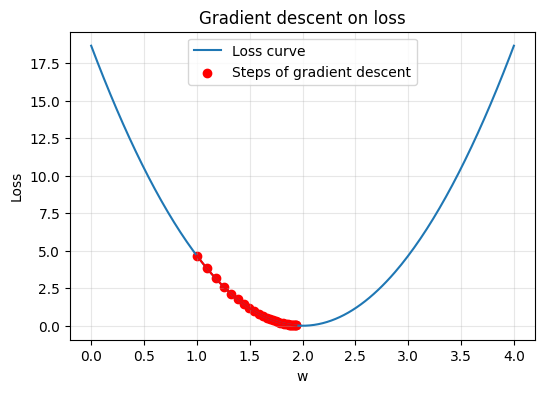

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# dataset
x = np.array([1, 2, 3])
y_true = np.array([2, 4, 6])

# model parameter
w = 1.0
lr = 0.01

# loss function
def loss(w):
    y_pred = w * x
    return np.mean((y_pred - y_true) ** 2)
 
# derivative of loss with respect to w
def dloss(w):
    y_pred = w * x
    return np.mean(2 * x * (y_pred - y_true))

# track values for plotting
ws = []
Ls = []

print("Start w:", w, "loss:", loss(w))

for step in range(30):
    ws.append(w)
    Ls.append(loss(w))
    slope = dloss(w)
    w = w - lr * slope
    print("Step", step + 1, "w:", round(w, 4), "loss:", round(loss(w), 4))

# prepare plot
ws_plot = np.linspace(0, 4, 200)
Ls_plot = [loss(wp) for wp in ws_plot]

plt.figure(figsize=(6, 4))
plt.plot(ws_plot, Ls_plot, label="Loss curve")
plt.scatter(ws, Ls, color="red", label="Steps of gradient descent")
plt.plot(ws, Ls, color="red")
plt.xlabel("w")
plt.ylabel("Loss")
plt.title("Gradient descent on loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
